# 03 — Baseline Model

This notebook evaluates a simple **naive baseline** for forecasting `Children in HHS Care`. The baseline uses the previous observed value as the prediction and keeps the train/test split chronological.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

candidates = [
    Path("data/processed_data.csv"),
    Path("UAC_Forecasting_Project/data/processed_data.csv"),
]
data_path = next((p for p in candidates if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "processed_data.csv was not found. Run 02_Feature_Engineering.ipynb first.\n"
        + "Checked:\n" + "\n".join(str(p) for p in candidates)
    )

df = pd.read_csv(data_path)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
target = "Children in HHS Care"
df[target] = pd.to_numeric(df[target], errors="coerce")
df = df.dropna(subset=["Date", target]).sort_values("Date").reset_index(drop=True)

print(f"Loaded: {data_path.resolve()}")
print(f"Dataset shape: {df.shape}")
display(df[["Date", target]].head())


Loaded: C:\Users\kapta\Downloads\UAC-Forecasting-Project-main\UAC-Forecasting-Project-main\UAC_Forecasting_Project\data\processed_data.csv
Dataset shape: (720, 14)


,Date,Children in HHS Care
0,2023-01-12,6566.0
1,2023-01-22,7122.0
2,2023-01-23,7280.0
3,2023-01-24,7433.0
4,2023-01-25,7538.0


In [2]:
# Chronological 80/20 train/test split
split_idx = int(len(df) * 0.80)

train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

if len(train) < 2 or len(test) < 1:
    raise ValueError("Not enough observations for an 80/20 chronological split.")

y_train = train[target]
y_test = test[target]

print(f"Train rows: {len(train)}")
print(f"Test rows:  {len(test)}")
print(f"Train period: {train['Date'].min().date()} → {train['Date'].max().date()}")
print(f"Test period:  {test['Date'].min().date()} → {test['Date'].max().date()}")


Train rows: 576
Test rows:  144
Train period: 2023-01-12 → 2025-05-13
Test period:  2025-05-14 → 2025-12-21


In [3]:
# Naive baseline:
# First test prediction = last observed training value.
# Each later prediction = previous actual test observation.
pred = test[target].shift(1)
pred.iloc[0] = train[target].iloc[-1]
pred = pred.astype(float)

baseline_results = pd.DataFrame({
    "Date": test["Date"].values,
    "Actual": y_test.values,
    "Prediction": pred.values,
})

display(baseline_results.head(10))


,Date,Actual,Prediction
0,2025-05-14,2394.0,2394.0
1,2025-05-15,2410.0,2394.0
2,2025-05-18,2437.0,2410.0
3,2025-05-19,2457.0,2437.0
4,2025-05-21,2467.0,2457.0
5,2025-05-22,2473.0,2467.0
6,2025-05-27,2504.0,2473.0
7,2025-05-28,2499.0,2504.0
8,2025-05-29,2506.0,2499.0
9,2025-06-01,2528.0,2506.0


In [4]:
# Evaluate the baseline
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

nonzero_actual = y_test != 0
if nonzero_actual.any():
    mape = (
        np.mean(
            np.abs(
                (y_test[nonzero_actual] - pred[nonzero_actual])
                / y_test[nonzero_actual]
            )
        ) * 100
    )
else:
    mape = np.nan

print(f"Baseline MAE : {mae:,.3f}")
print(f"Baseline RMSE: {rmse:,.3f}")
print(f"Baseline MAPE: {mape:,.2f}%")


Baseline MAE : 10.389
Baseline RMSE: 14.172
Baseline MAPE: 0.46%


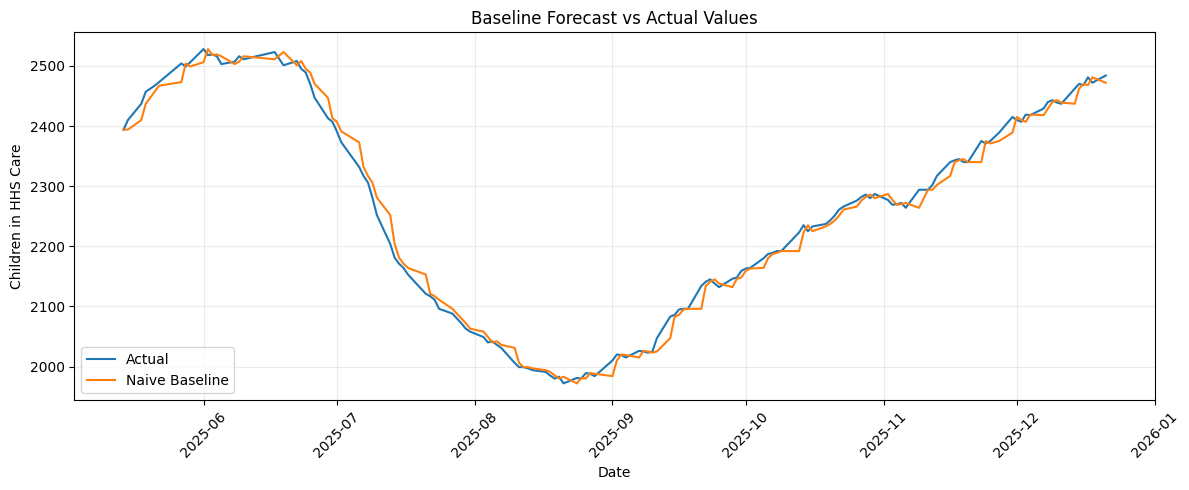

In [5]:
# Visualize actual vs baseline prediction
plt.figure(figsize=(12, 5))
plt.plot(baseline_results["Date"], baseline_results["Actual"], label="Actual")
plt.plot(baseline_results["Date"], baseline_results["Prediction"], label="Naive Baseline")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.title("Baseline Forecast vs Actual Values")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [6]:
# Save baseline predictions for later model comparison
results_dir = Path("data")
if not results_dir.exists():
    results_dir = Path("UAC_Forecasting_Project/data")
results_dir.mkdir(parents=True, exist_ok=True)

results_path = results_dir / "baseline_predictions.csv"
baseline_results.to_csv(results_path, index=False)

print(f"Baseline predictions saved to: {results_path.resolve()}")


Baseline predictions saved to: C:\Users\kapta\Downloads\UAC-Forecasting-Project-main\UAC-Forecasting-Project-main\UAC_Forecasting_Project\data\baseline_predictions.csv
